In [1]:
from CUORETopology import TopologyAnalysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.transforms import Affine2D

In [ ]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 2, 
          "EnergyRange": [2080, 2120],
          "InvalidChannels": 'InvalidChannels/M2SE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M2SE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M2SE511_reso_all.txt',
          "EnergyDist": 511}

M2SE511Sort = TopologyAnalysis(config)

singleEscape = M2SE511Sort.SingleEscapeSort()
reducedSingleEscape = M2SE511Sort.ChannelRemoval(singleEscape)

NTDEvents, noNTDEvents = M2SE511Sort.NTD_Sort(reducedSingleEscape)

Face, Edge, Corner, NoNe= M2SE511Sort.M2Topology_Sort(noNTDEvents)

NTDEvents_2100, NTDEvents_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(NTDEvents)
noNTD_2100, noNTD_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(noNTDEvents)

data = [i for i in NTDEvents_511 if 495 <= i <= 530]

M2SE511NTDmu, M2SE511NTDmu_err, M2SE511NTDsigma, M2SE511NTDsigma_err, NTDchi2= M2SE511Sort.NormGuassianExpMinimizer(data, 'NTD M2 SE 511 keV (0.5 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 2*int(max(data) - min(data)))

dataNoNTD = [i for i in noNTD_511 if 495 <= i <= 530]

M2SE511nonNTDmu, M2SE511nonNTDmu_err, M2SE511nonNTDsigma, M2SE511nonNTDsigma_err, M2SE511nonNTDchi2= M2SE511Sort.NormGuassianExpMinimizer(dataNoNTD, 'No-NTD M2 SE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(dataNoNTD) - min(dataNoNTD)))

In [ ]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 3, 
          "EnergyRange": [2070, 2130],
          "InvalidChannels": 'InvalidChannels/M3SE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M3SE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M3SE511_reso_all.txt',
          "EnergyDist": 511}

M3SE511Sort = TopologyAnalysis(config)

M3singleEscape = M3SE511Sort.SingleEscapeSort()
M3reducedSingleEscape = M3SE511Sort.ChannelRemoval(M3singleEscape)

NTDEvents, noNTDEvents = M3SE511Sort.NTD_Sort(M3reducedSingleEscape)
NonNTD_2100, NonNTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(noNTDEvents)

NTD_2100, NTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NTDEvents)

data = [i for i in NTD_511 if 490 <= i <= 540]
M3SE511NTDmu, M3SE511NTDmu_err, M3SE511NTDsigma, M3SE511NTDsigmaerr, M3SE511NTDchi2 = M3SE511Sort.NormGuassianExpMinimizer(data, 'NTD M3 SE 511 keV (1 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], int(max(data)-min(data)))

dataNonNTD = [i for i in NonNTD_511 if 490 <= i <= 540]
M3SE511nonNTDmu, M3SE511nonNTDmu_err, M3SE511nonNTDsigma, M3SE511nonNTDsigmaerr, M3SE511nonNTDchi2 = M3SE511Sort.NormGuassianExpMinimizer(dataNonNTD, 'Non-NTD M3 SE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(dataNonNTD)-min(dataNonNTD)))

In [ ]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 3, 
          "EnergyRange": [500, 520],
          "InvalidChannels": 'InvalidChannels/M3DE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M3DE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M3DE511_reso_all.txt',
          "EnergyDist": 511}

M3DE511Sort = TopologyAnalysis(config)

doubleEscape = M3DE511Sort.DoubleEscapeSort()
reducedDoubleEscape = M3DE511Sort.ChannelRemoval(doubleEscape)

NTDEvents, noNTDEvents = M3DE511Sort.NTD_Sort(reducedDoubleEscape)

M3DE511NTDmu, M3DE511NTDmu_err, M3DE511NTDsigma, M3DE511NTDsigma_err, M3DE511NTDchi2= M3DE511Sort.NormGuassianExpMinimizer(NTD_511, 'NTD M3 DE 511 keV (0.5 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 2*int(max(NTD_511) - min(NTD_511)))
M3DE511nonNTDmu, M3DE511nonNTDmu_err, M3DE511nonNTDsigma, M3DE511nonNTDsigma_err, M3DE511nonNTDchi2= M3DE511Sort.NormGuassianExpMinimizer(nonNTD_511, 'Non-NTD M3 DE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(nonNTD_511) - min(nonNTD_511)))

nonNTD_1600_cut = [i for i in nonNTD_1600 if 1581 < i < 1605]
M3DE1600nonNTDmu, M3DE1600nonNTDmu_err, M3DE1600nonNTDsigma, M3DE1600nonNTDsigma_err, M3DE1600nonNTDchi2= M3DE511Sort.NormGuassianExpMinimizer(nonNTD_1600_cut, 'Non-NTD M3 DE 1593.5 keV (0.25 keV bins)', [1593, 2.3, 0.11, 6.89713150e-03], 4*int(max(nonNTD_1600_cut) - min(nonNTD_1600_cut)))

NTD_1600_cut = [i for i in NTD_1600 if 1581 < i < 1605]
M3DE1600NTDmu, M3DE1600NTDmu_err, M3DE1600NTDsigma, M3DE1600NTDsigma_err, M3DE1600NTDchi2= M3DE511Sort.NormGuassianExpMinimizer(NTD_1600_cut, 'NTD M3 DE 1593.5 keV (0.5 keV bins)', [1593, 2.3, 0.11, 6.89713150e-03], 2*int(max(NTD_1600_cut) - min(NTD_1600_cut)))

In [24]:
M2SE2100NonNTDmu = 2104.1533603001835
M2SE2100NonNTDsigma = 2.991661546326953

M2SE2100NTDmu = 2104.4601974247385
M2SE2100NTDsigma = 2.9829010963882943

In [25]:
M3SE2100NonNTDmu = 2104.2684430758936
M3SE2100NTDmu = 2104.6374207325075

M3SE2100NonNTDsigma = 2.9656411496027695
M3SE2100NTDsigma = 2.481633976796041

ValueError: 'paleblue' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

<Figure size 640x480 with 0 Axes>

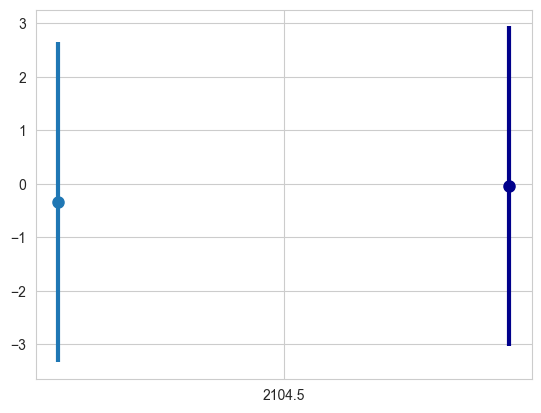

In [ ]:
from matplotlib.transforms import Affine2D
plt.figure()
energy = ['511', '1593.5', '2104.5']

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.14, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.14, 0.0) + ax.transData
trans3 = Affine2D().translate(+0.16, 0.0) + ax.transData
trans4 = Affine2D().translate(+0.18, 0.0) + ax.transData

ax.errorbar(energy[-1], M2SE2100NonNTDmu-2104.5, yerr=M2SE2100NonNTDsigma, transform=trans1, ms=8, elinewidth=3, fmt='o', label='M2SE Non-NTD Face Biases')
ax.errorbar(energy[-1], M2SE2100NTDmu-2104.5, yerr=M2SE2100NTDsigma, transform=trans2, fmt='o',ms=8, elinewidth=3, color='darkblue', label='M2SE NTD Face Biases')

ax.errorbar(energy[-1], M3SE2100NonNTDmu-2104.5, yerr=M3SE2100NonNTDsigma, transform=trans3, ms=8, elinewidth=3, fmt='s', color = 'blue',label='M3SE Non-NTD Face Biases')
ax.errorbar(energy[-1], M3SE2100NTDmu-2104.5, yerr=M3SE2100NTDsigma, transform=trans4, fmt='s',ms=8, elinewidth=3, color='darkblue', label='M3SE NTD Face Biases')


plt.legend(loc='upper right',fontsize=9)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single: 2104.5 keV Mean Biases')
plt.ylabel(r'$E_{reconstructed}-E_{expected}$ (keV)', fontsize=12)